# EEG Decoding: Citrus vs Cyclohexane

Apoorv Saraogee · MSDS 590 · Dr. Srinivasan

Source data: https://zenodo.org/records/6387085 (public). Contains ProcData folder.
All paths are repository-relative.

1. **Data** — loads Kato et al. ProcData folder, then applies the preprocessing pipeline: pre-odor baseline subtract → select 28 analysis bins ∈ [0, 1.5]s @ 100 Hz → add a zero-crossing-rate (ZCR) feature channel → per-subject z-score. Creates pickle file kato_cit_cyc_grid2d_events.pkl.

2. **Model** — a CNN-LSTM trained per fold under `GroupKFold(n_splits=5)` across all 22 subjects (subjects disjoint between fit and val). Recipe: `TF_SEED=145`, `epochs=30`, `batch_size=64`, no EarlyStopping. Reports per-fold accuracy + analytical t-based 95% CI and aggregate OOF metrics. Creates 5 keras model files.

3. **Results** — Occlusion for each fold's held-out trials, every spatial / temporal / spatiotemporal cell is replaced with the per-trial pre-stim baseline of the same channel (Grubov et al. 2026, Eq. 8; adapted from Zeiler & Fergus 2014). The importance metric is mean **|Δp|** — absolute change in the sigmoid output — aggregated across the 5 folds.


## 1. Data

**a (imports + helpers)** defines all constants and helper functions used downstream — file paths, model recipe (`BEST_CFG`), training/evaluation utilities, the BioSemi 64ch → 2-D grid mapping, and the CNN-LSTM builder.

**b** builds (or loads) the trial-level pickle `kato_cit_cyc_grid2d_events.pkl` from Kato's ProcData  `.mat` files. Set `FORCE_REBUILD_FROM_PROCDATA = True` to regenerate from scratch (requires `Kato_et_al/ProcData/EEG/`).

**c** applies the preprocessing pipeline: pre-odor [-0.5, 0)s baseline subtract → select 28 analysis bins ∈ [0, 1.5]s @ 100 Hz → add a ZCR feature channel → per-subject z-score across that subject's own trials. The ZCR channel is justified as a design choice.


In [2]:
# ── Imports + constants + helpers ─────────────────────────────────────────────
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import json, random
from pathlib import Path

import h5py
import mne
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy import stats as sps
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

BASE_DIR = Path('Kato_et_al')
PICKLE_PATH = Path('kato_cit_cyc_grid2d_events.pkl')
TEMP_DIR = Path('temp')
MODEL_DIR = Path('models')
TEMP_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

EPOCH_TMIN, EPOCH_TMAX = -0.5, 1.5
ANALYSIS_TMIN, ANALYSIS_TMAX = 0.0, 1.5
RESAMPLE_HZ, SPATIAL_WINDOW_MS, N_BINS = 100, 500, 28
N_EEG_CH = 64
ODOR_CIT, ODOR_CYC = 6, 21
TARGET_ODOR_INFO = {
    6:  {'smell': 'Cit', 'response_type': 'positive'},
    21: {'smell': 'Cyc', 'response_type': 'negative'},
}

PRIMARY_SEED      = 42      # split RNG
TF_SEED           = 145     # TF seed for training
N_OUTER_SPLITS    = 10
TEST_SIZE         = 0.25
BEST_SPLIT_IDX    = 4       # 1-indexed
N_CV_FOLDS        = 5
THR               = 0.5
TRAIN_EPOCHS      = 30
TRAIN_VERBOSE     = 1

BEST_CFG = {
    'conv_filters': 40, 'kernel_size': (5, 5), 'feature_head': 'gap',
    'lstm_units': 384, 'bidirectional': False, 'dense_units': 64,
    'dropout': 0.30, 'lr': 1e-4, 'batch_size': 64, 'label_smoothing': 0.00,
}

np.random.seed(PRIMARY_SEED)
tf.random.set_seed(PRIMARY_SEED)

def build_time_axis(n):
    return EPOCH_TMIN + np.arange(n, dtype=np.float64) / float(RESAMPLE_HZ)

def select_analysis_bin_indices(n):
    ta = build_time_axis(n)
    v = np.where((ta >= ANALYSIS_TMIN) & (ta <= ANALYSIS_TMAX))[0]
    if v.size < N_BINS:
        raise RuntimeError(f'Only {v.size} valid timepoints in [{ANALYSIS_TMIN}, {ANALYSIS_TMAX}]s')
    pick = np.linspace(0, v.size - 1, N_BINS, dtype=int)
    sel = v[pick]
    return sel, ta[sel]

def add_zero_crossing_channel(x):
    arr = np.asarray(x, dtype=np.float32); eeg = arr[..., 0]
    sign = np.sign(eeg); sign[sign == 0] = 1
    zc = np.zeros_like(eeg, dtype=np.float32)
    zc[:, 1:, :, :] = (sign[:, 1:, :, :] * sign[:, :-1, :, :] < 0).astype(np.float32)
    return np.concatenate([arr, zc[..., np.newaxis]], axis=-1)

def read_biosemi_coordinates(p):
    cd = pd.read_csv(p, sep='\t', engine='python')
    cd.columns = [str(c).strip() for c in cd.columns]
    for col in ['Number','X','Y','Z','theta','radius','datachan']:
        if col in cd.columns:
            cd[col] = pd.to_numeric(cd[col], errors='coerce')
    if 'datachan' in cd.columns and cd['datachan'].notna().any():
        cd = cd.loc[cd['datachan']==1, ['Number','labels','X','Y','Z','theta','radius']].copy()
    else:
        cd = cd.loc[:63, ['Number','labels','X','Y','Z','theta','radius']].copy()
    cd = cd.rename(columns={'labels':'channel'}).sort_values('Number').reset_index(drop=True)
    cd['channel'] = cd['channel'].astype(str).str.strip()
    cd[['X','Y','Z','theta','radius']] = cd[['X','Y','Z','theta','radius']].astype(float)
    th = np.deg2rad(cd['theta'].values)
    cd['x2d'] = cd['radius'].values * np.sin(th)
    cd['y2d'] = cd['radius'].values * np.cos(th)
    return cd

def make_xy_grid_mapping(cd, max_dim=25):
    x2d, y2d = cd['x2d'].values, cd['y2d'].values
    xs = max(x2d.max()-x2d.min(), 1e-8); ys = max(y2d.max()-y2d.min(), 1e-8)
    for nr in range(7, max_dim+1):
        for nc in range(7, max_dim+1):
            if nr*nc < len(cd): continue
            ci = np.round((x2d - x2d.min())/xs*(nc-1)).astype(int)
            ri = np.round((y2d.max() - y2d)/ys*(nr-1)).astype(int)
            if len(set(zip(ri.tolist(), ci.tolist()))) == len(cd):
                return nr, nc, ri, ci
    raise RuntimeError('No collision-free grid mapping')

def epoch_to_2d_grid(epoch_data, row_idx, col_idx, n_rows, n_cols):
    n_times = epoch_data.shape[-1]
    grid = np.zeros((n_rows, n_cols, n_times), dtype=np.float32)
    for ch, (r, c) in enumerate(zip(row_idx, col_idx)):
        grid[r, c, :] = epoch_data[ch]
    return grid

def load_subject_procdata(subject_id, proc_dir=BASE_DIR / 'ProcData' / 'EEG', ced_path=BASE_DIR / 'biosemi64.ced'):
    mat_path = Path(proc_dir) / subject_id / 'erp_v1.mat'
    if not mat_path.exists():
        return pd.DataFrame(), None
    coord_df = read_biosemi_coordinates(ced_path)
    n_rows, n_cols, row_idx, col_idx = make_xy_grid_mapping(coord_df)
    with h5py.File(mat_path, 'r') as f:
        erp = f['erp'][:]; log = f['log'][:]; times = f['times'][:].squeeze()
    odor_nums = log[1, :]; run_nums = log[4, :]
    stride = int(round(500 / RESAMPLE_HZ))
    t_idx = np.where((times >= EPOCH_TMIN * 1000) & (times <= EPOCH_TMAX * 1000))[0]
    time_indices = t_idx[::stride]
    rows = []
    for trial_i in range(erp.shape[0]):
        odor_num = int(odor_nums[trial_i])
        if odor_num not in TARGET_ODOR_INFO: continue
        eeg_ch_time = erp[trial_i][time_indices, :N_EEG_CH].T
        info = TARGET_ODOR_INFO[odor_num]
        rows.append({
            'subject': subject_id,
            'run_modality': f'run-{int(run_nums[trial_i]):02d}',
            'trial': int(log[0, trial_i]),
            'odor_number': odor_num,
            'smell': info['smell'],
            'response_type': info['response_type'],
            'data': epoch_to_2d_grid(eeg_ch_time, row_idx, col_idx, n_rows, n_cols),
        })
    if not rows:
        return pd.DataFrame(), None
    meta = {'grid_shape': (n_rows, n_cols),
            'channel_positions': coord_df,
            'row_idx': row_idx, 'col_idx': col_idx}
    return pd.DataFrame(rows), meta

def build_kato_cit_cyc_dataframe(proc_dir=BASE_DIR / 'ProcData' / 'EEG', ced_path=BASE_DIR / 'biosemi64.ced'):
    all_dfs, meta = [], None
    for sd in sorted(Path(proc_dir).iterdir()):
        if not sd.is_dir(): continue
        df, m = load_subject_procdata(sd.name, proc_dir, ced_path)
        if not df.empty:
            all_dfs.append(df)
            if meta is None: meta = m
    if not all_dfs:
        return pd.DataFrame(), None
    return pd.concat(all_dfs, ignore_index=True), meta

def build_best_model(input_shape, cfg):
    """Identical to v1's build_best_model (no internal seed setting).
    Determinism is controlled by the caller via tf.random.set_seed / np.random.seed."""
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(cfg['conv_filters'], cfg['kernel_size'], activation='relu', padding='same'))(inp)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    if cfg['feature_head'] == 'gap':
        x = tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D())(x)
    else:
        x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
    lstm = tf.keras.layers.LSTM(cfg['lstm_units'], return_sequences=False, dropout=cfg['dropout'])
    x = tf.keras.layers.Bidirectional(lstm)(x) if cfg['bidirectional'] else lstm(x)
    x = tf.keras.layers.Dense(cfg['dense_units'], activation='relu')(x)
    x = tf.keras.layers.Dropout(cfg['dropout'])(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['lr']),
              loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=cfg['label_smoothing']),
              metrics=['accuracy'])
    return m

def seed_everything(seed):
    """Seed Python, NumPy and TensorFlow - call once before each model build/fit."""
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def analytical_ci(vals, alpha=0.05):
    vals = np.asarray(vals, dtype=np.float64)
    if vals.size <= 1:
        m = float(vals.mean()) if vals.size == 1 else float('nan')
        return m, m
    se = vals.std(ddof=1) / np.sqrt(vals.size)
    t_crit = sps.t.ppf(1.0 - alpha / 2.0, df=vals.size - 1)
    m = vals.mean()
    return float(m - t_crit * se), float(m + t_crit * se)

def metric_pack(y_true, p_prob, thr=THR):
    p_pred = (p_prob >= thr).astype(int)
    return {
        'accuracy'          : float(accuracy_score(y_true, p_pred)),
        'balanced_accuracy' : float(balanced_accuracy_score(y_true, p_pred)),
        'f1'                : float(f1_score(y_true, p_pred, zero_division=0)),
        'roc_auc'           : float(roc_auc_score(y_true, p_prob)) if len(set(y_true.tolist())) == 2 else float('nan'),
        'cm'                : confusion_matrix(y_true, p_pred, labels=[0,1]).tolist(),
    }

print('Constants + helpers loaded.')

/Users/asaraog/fsl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Constants + helpers loaded.


In [3]:
# ── Build or load the trial-level pickle ─────────────────────────────────
USE_PICKLE_IF_AVAILABLE = True
FORCE_REBUILD_FROM_PROCDATA = False

if FORCE_REBUILD_FROM_PROCDATA:
    print('FORCE_REBUILD_FROM_PROCDATA=True -> rebuilding from ProcData.')
    multi_df, kato_metadata = build_kato_cit_cyc_dataframe()
    if multi_df.empty:
        raise RuntimeError(f"No ProcData found under {BASE_DIR / 'ProcData' / 'EEG'}.")
    multi_df.to_pickle(PICKLE_PATH)
    print(f'Built dataframe and saved {PICKLE_PATH} with {len(multi_df)} events.')
elif USE_PICKLE_IF_AVAILABLE and PICKLE_PATH.exists():
    print(f'Loading existing pickle {PICKLE_PATH}.')
    multi_df = pd.read_pickle(PICKLE_PATH)
    coord_df = read_biosemi_coordinates(BASE_DIR / 'biosemi64.ced')
    n_rows, n_cols, row_idx, col_idx = make_xy_grid_mapping(coord_df)
    kato_metadata = {'grid_shape': (n_rows, n_cols),
                     'channel_positions': coord_df,
                     'row_idx': row_idx, 'col_idx': col_idx}
else:
    print('No pickle found and USE_PICKLE_IF_AVAILABLE=False -> rebuilding from ProcData.')
    multi_df, kato_metadata = build_kato_cit_cyc_dataframe()
    if multi_df.empty:
        raise RuntimeError(f"No ProcData found under {BASE_DIR / 'ProcData' / 'EEG'}.")
    multi_df.to_pickle(PICKLE_PATH)
    print(f'Built dataframe and saved {PICKLE_PATH} with {len(multi_df)} events.')

print(f'Loaded {len(multi_df)} trials, {multi_df["subject"].nunique()} subjects.')
print('Counts per odor:')
print(multi_df['odor_number'].value_counts().sort_index().to_string())

Loading existing pickle kato_cit_cyc_grid2d_events.pkl.
Loaded 1243 trials, 22 subjects.
Counts per odor:
odor_number
6     620
21    623


In [4]:
# ── Preprocessing pipeline: baseline-subtract → bins → ZCR → z-score ──────
work = multi_df[multi_df['odor_number'].isin([ODOR_CIT, ODOR_CYC])].copy().reset_index(drop=True)
y_all = (work['odor_number'].values == ODOR_CYC).astype(np.int32)
g_all = work['subject'].astype(str).values
arr   = np.stack(work['data'].values).astype(np.float32)   # (N, H, W, T)
x_full = np.transpose(arr, (0, 3, 1, 2))[..., np.newaxis]   # (N, T, H, W, 1)

ta_full = build_time_axis(x_full.shape[1])
pm = ta_full < 0.0
if pm.any():
    x_full = x_full - x_full[:, pm, :, :, :].mean(axis=1, keepdims=True)
    print(f'Baseline subtracted across {int(pm.sum())} pre-odor samples in [{EPOCH_TMIN:.2f}, 0.00)s.')

idx_bins, bin_times = select_analysis_bin_indices(x_full.shape[1])
x_bin = add_zero_crossing_channel(x_full[:, idx_bins, :, :, :])

# Keep per-subject mu/sd so the same normalisation can be applied to the
# pre-stim baseline tensor built below.
mu_by_subj, sd_by_subj = {}, {}
x_all = x_bin.copy()
for s in sorted(set(g_all.tolist())):
    m = g_all == s
    mu = x_bin[m].mean(axis=0, keepdims=True)
    sd = x_bin[m].std(axis=0, keepdims=True) + 1e-6
    mu_by_subj[s], sd_by_subj[s] = mu, sd
    x_all[m] = (x_bin[m] - mu) / sd

# ── Pre-stim baseline tensor (Grubov-style occlusion replacement) ──────────
# We build `x_baseline` with the SAME (N, N_BINS, H, W, C=2) shape as `x_all`,
# Same (N, N_BINS, H, W, 2) shape as `x_all`, sampled from the pre-stim
# window [-0.5, 0)s and pushed through the same ZCR + per-subject z-score
# pipeline so the values live in the model's training distribution.
# §3 uses this as the in-distribution replacement when occluding any cell.
pre_indices = np.where(pm)[0]
pick_pre    = np.linspace(0, pre_indices.size - 1, N_BINS, dtype=int)
sel_pre     = pre_indices[pick_pre]
x_pre_raw   = x_full[:, sel_pre, :, :, :]                              # (N, 28, H, W, 1)
x_pre_bin   = add_zero_crossing_channel(x_pre_raw)                     # (N, 28, H, W, 2)
x_baseline  = np.empty_like(x_pre_bin)
for s in sorted(set(g_all.tolist())):
    m = g_all == s
    x_baseline[m] = (x_pre_bin[m] - mu_by_subj[s]) / sd_by_subj[s]

print(f'trials             : {len(y_all)}  (pos={int(y_all.sum())}, neg={int(len(y_all)-y_all.sum())})')
print(f'subjects           : {len(set(g_all.tolist()))}')
print(f'input tensor shape : {x_all.shape}   # (N, T={N_BINS}, H, W, C=2)')
print(f'baseline tensor    : {x_baseline.shape}   # from pre-stim [{EPOCH_TMIN:.2f}, 0.00)s, same shape')
print(f'bin times          : {bin_times[0]:.3f}, {bin_times[1]:.3f}, …, {bin_times[-1]:.3f}  (s)')
print(f'trials             : {len(y_all)}  (pos={int(y_all.sum())}, neg={int(len(y_all)-y_all.sum())})')

Baseline subtracted across 50 pre-odor samples in [-0.50, 0.00)s.
trials             : 1243  (pos=623, neg=620)
subjects           : 22
input tensor shape : (1243, 28, 10, 11, 2)   # (N, T=28, H, W, C=2)
baseline tensor    : (1243, 28, 10, 11, 2)   # from pre-stim [-0.50, 0.00)s, same shape
bin times          : 0.000, 0.050, …, 1.490  (s)
trials             : 1243  (pos=623, neg=620)


## 2. Model + 5-fold subject-aware CV

Pure **5-fold `GroupKFold` cross-validation** across **all 22 subjects** — different subjects are completely held out for each fold. Each fold trains a fresh CNN-LSTM under the same recipe (`epochs=30`, `batch_size=64`, `verbose=1`, no EarlyStopping). Per-fold validation predictions are concatenated into a single out-of-fold (OOF) vector — every trial is predicted exactly once, while its subject is in the held-out fold — and metrics (accuracy, F1, ROC-AUC, confusion matrix) are reported on that aggregate plus the per-fold breakdown with analytical t-based 95% CI on accuracy.

**a (fold partition, model summary + 5-fold CV training / load)** shows which subjects fall in each held-out fold, prints the CNN-LSTM Keras layer summary, then trains a fresh model per fold (or reloads `models/fold_*.keras` if `RETRAIN=False`) and collects per-fold + OOF predictions.

**b (aggregate OOF metrics + per-fold table)** prints the per-fold accuracy/F1/AUC table, the cross-fold mean ± t-based 95% CI, and the pooled OOF + aggregated training confusion matrices.

**c (ZCR feature ablation)** retrains the same architecture on the voltage-only input (no ZCR channel) under the same 5 GroupKFold splits and reports the paired per-fold lift from adding ZCR (count of folds where ZCR helps, mean lift in pp, 95% CI, one-sided sign test).


In [17]:
# ── §2a/b Fold partition + model summary + 5-fold subject-aware CV ─────────
print(f'Dataset: n={len(y_all)} trials, {len(set(g_all.tolist()))} subjects')
print(f'\nCV fold subject partition ({N_CV_FOLDS}-fold GroupKFold, all subjects):')
for k, (_, val) in enumerate(GroupKFold(n_splits=N_CV_FOLDS).split(x_all, y_all, groups=g_all), start=1):
    val_subj = sorted(set(g_all[val].tolist()))
    print(f'  fold {k}: n_val={len(val)}, {len(val_subj)} subj -> {val_subj}')

seed_everything(TF_SEED)
demo = build_best_model(tuple(x_all.shape[1:]), BEST_CFG)
demo.summary(line_length=90)

# ── 5-fold subject-aware CV across ALL subjects ────────────────────
# RETRAIN=False just reloads existing fold_*.keras files instead of retraining.
RETRAIN = False

input_shape = tuple(x_all.shape[1:])
gkf = GroupKFold(n_splits=N_CV_FOLDS)
fold_rows = []
fold_iter = list(enumerate(gkf.split(x_all, y_all, groups=g_all), start=1))

# OOF (out-of-fold) predictions: each trial gets predicted exactly once,
# while its subject is in the held-out fold.
oof_p = np.full(len(y_all), np.nan, dtype=np.float64)

for fold_num, (fit_idx, val_idx) in tqdm(fold_iter, desc='5-fold CV', total=N_CV_FOLDS, unit='fold'):
    model_path = MODEL_DIR / f'fold_{fold_num}.keras'
    g_val_set = sorted(set(g_all[val_idx].tolist()))
    X_fit, y_fit = x_all[fit_idx], y_all[fit_idx]
    X_val, y_val = x_all[val_idx], y_all[val_idx]

    if RETRAIN or not model_path.exists():
        print(f'\n=== fold {fold_num}: fit n={len(fit_idx)} ({len(set(g_all[fit_idx].tolist()))} subj),',
              f' val n={len(val_idx)} ({len(g_val_set)} subj) ===')
        print(f'  val subjects: {g_val_set}')
        seed_everything(TF_SEED)
        model = build_best_model(input_shape, BEST_CFG)
        hist = model.fit(
            X_fit, y_fit,
            validation_data=(X_val, y_val),
            epochs=TRAIN_EPOCHS,
            batch_size=BEST_CFG['batch_size'],
            verbose=TRAIN_VERBOSE,
        )
        model.save(model_path)
        epochs_ran = len(hist.history['loss'])
    else:
        print(f'\n=== fold {fold_num}: loading existing {model_path.name} ===')
        model = tf.keras.models.load_model(model_path)
        epochs_ran = -1

    # Post-fit predictions on the training fold (memorization check; ~upper bound).
    p_fit = model.predict(X_fit, verbose=0).ravel()
    m_fit = metric_pack(y_fit, p_fit)

    p_val = model.predict(X_val, verbose=0).ravel()
    oof_p[val_idx] = p_val
    m = metric_pack(y_val, p_val)
    fold_rows.append({
        'fold': fold_num,
        'n_fit': int(len(fit_idx)),
        'n_val': int(len(val_idx)),
        'val_subjects': ';'.join(g_val_set),
        'epochs_ran': int(epochs_ran),
        'model_path': str(model_path),
        **{f'train_{k}': v for k, v in m_fit.items() if k != 'cm'},
        'train_cm': json.dumps(m_fit['cm']),
        **{f'val_{k}': v for k, v in m.items() if k != 'cm'},
        'val_cm': json.dumps(m['cm']),
    })
    print(f"  -> train acc={m_fit['accuracy']:.4f}  val acc={m['accuracy']:.4f}  "
          f"gap={m_fit['accuracy']-m['accuracy']:+.4f}  "
          f"bal_acc={m['balanced_accuracy']:.4f}  f1={m['f1']:.4f}  auc={m['roc_auc']:.4f}")
    del model
    tf.keras.backend.clear_session()

assert not np.isnan(oof_p).any(), 'some trials were never assigned to a val fold'
cv_df = pd.DataFrame(fold_rows)
cv_df.to_csv(TEMP_DIR / 'cv_per_fold.csv', index=False)
print('\nSaved per-fold CV metrics.')

Dataset: n=1243 trials, 22 subjects

CV fold subject partition (5-fold GroupKFold, all subjects):
  fold 1: n_val=236, 4 subj -> ['KM26_s03', 'KM26_s09', 'KM32_s05', 'KM32_s10']
  fold 2: n_val=271, 5 subj -> ['KM26_s08', 'KM32_s02', 'KM32_s07', 'KM32_s12', 'KM32_s16']
  fold 3: n_val=233, 4 subj -> ['KM26_s04', 'KM32_s09', 'KM32_s14', 'KM32_s15']
  fold 4: n_val=233, 4 subj -> ['KM26_s01', 'KM26_s06', 'KM32_s01', 'KM32_s08']
  fold 5: n_val=270, 5 subj -> ['KM26_s02', 'KM26_s05', 'KM32_s11', 'KM32_s13', 'KM32_s17']


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)              │ (None, 28, 10, 11, 2)        │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)    │ (None, 28, 10, 11, 40)       │           2,040 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed)  │ (None, 28, 10, 11, 40)       │             160 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed)  │ (None, 28, 5, 5, 40)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed)  │ (None, 28, 40)               │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ lstm (LSTM)                           │ (None, 384)                  │         652,800 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 64)                   │          24,640 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 64)                   │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 1)                    │              65 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 679,705 (2.59 MB)

 Trainable params: 679,625 (2.59 MB)

...


=== fold 4: loading existing fold_4.keras ===


5-fold CV:  80%|████████  | 4/5 [00:17<00:04,  4.19s/fold]

  -> train acc=0.6020  val acc=0.5494  gap=+0.0526  bal_acc=0.5489  f1=0.4928  auc=0.5553

=== fold 5: loading existing fold_5.keras ===


5-fold CV: 100%|██████████| 5/5 [00:20<00:00,  4.16s/fold]

  -> train acc=0.6115  val acc=0.6222  gap=-0.0107  bal_acc=0.6219  f1=0.6383  auc=0.6440

Saved per-fold CV metrics.


In [7]:
# ── Aggregate OOF metrics + per-fold summary + analytical t-based CI ─────────
print('=== Per-fold metrics (train = post-fit on X_fit; val = held-out) ===')
show_cols = ['fold','n_fit','n_val','val_subjects','epochs_ran',
             'train_accuracy','val_accuracy','val_balanced_accuracy','val_f1','val_roc_auc']
print(cv_df[show_cols].round(4).to_string(index=False))

cv_acc      = cv_df['val_accuracy'].to_numpy()
cv_train    = cv_df['train_accuracy'].to_numpy()
cv_gap      = cv_train - cv_acc
ci_lo, ci_hi = analytical_ci(cv_acc)
print(f'\n=== Per-fold CV accuracy summary ===')
print(f'  mean train acc    : {cv_train.mean():.4f}  +/- {cv_train.std(ddof=1):.4f}')
print(f'  mean val   acc    : {cv_acc.mean():.4f}  +/- {cv_acc.std(ddof=1):.4f}')
print(f'  mean train-val gap: {cv_gap.mean():+.4f}  +/- {cv_gap.std(ddof=1):.4f}  (small gap = minimal overfit)')
print(f'  95% analytical CI (val acc, t-based): [{ci_lo:.4f}, {ci_hi:.4f}]')

# --- Aggregated out-of-fold metrics (every trial predicted exactly once) ---
oof_metrics = metric_pack(y_all, oof_p)
print(f'\n=== Aggregated OOF metrics (n={len(y_all)} trials, every trial held out once) ===')
print(f"  accuracy          : {oof_metrics['accuracy']:.4f}")
print(f"  balanced_accuracy : {oof_metrics['balanced_accuracy']:.4f}")
print(f"  f1                : {oof_metrics['f1']:.4f}")
print(f"  roc_auc           : {oof_metrics['roc_auc']:.4f}")
print(f"  confusion matrix  : {oof_metrics['cm']}   (rows=true, cols=pred; 0=Cit, 1=Cyc)")
cm_arr = np.array(oof_metrics['cm'], dtype=np.float64)
cm_row_pct = cm_arr / cm_arr.sum(axis=1, keepdims=True) * 100.0
print(f"  confusion matrix %% (row-normalized, rows=true, cols=pred; 0=Cit, 1=Cyc):")
print(f"               pred=Cit   pred=Cyc")
print(f"    true=Cit:  {cm_row_pct[0,0]:7.2f}%   {cm_row_pct[0,1]:7.2f}%")
print(f"    true=Cyc:  {cm_row_pct[1,0]:7.2f}%   {cm_row_pct[1,1]:7.2f}%")

# Aggregated training confusion matrix (concatenated across folds).
train_cms = [np.array(json.loads(s)) for s in cv_df['train_cm'].tolist()]
train_cm_total = np.sum(train_cms, axis=0)
train_total = int(train_cm_total.sum())
train_correct = int(train_cm_total[0, 0] + train_cm_total[1, 1])
train_row_pct = train_cm_total / train_cm_total.sum(axis=1, keepdims=True) * 100.0
print(f"\n=== Aggregated training confusion matrix (sum across folds, n={train_total} fit predictions) ===")
print(f"  overall train acc : {train_correct/train_total:.4f}  ({train_correct}/{train_total})")
print(f"  confusion matrix  : {train_cm_total.tolist()}")
print(f"               pred=Cit   pred=Cyc")
print(f"    true=Cit:  {train_row_pct[0,0]:7.2f}%   {train_row_pct[0,1]:7.2f}%")
print(f"    true=Cyc:  {train_row_pct[1,0]:7.2f}%   {train_row_pct[1,1]:7.2f}%")

(TEMP_DIR / 'cv_eval.json').write_text(json.dumps({
    'n_folds'              : N_CV_FOLDS,
    'n_trials'             : int(len(y_all)),
    'n_subjects'           : int(len(set(g_all.tolist()))),
    'tf_seed'              : TF_SEED,
    'epochs'               : TRAIN_EPOCHS,
    'batch_size'           : BEST_CFG['batch_size'],
    'per_fold_train_acc'   : cv_train.tolist(),
    'per_fold_val_acc'     : cv_acc.tolist(),
    'per_fold_gap'         : cv_gap.tolist(),
    'cv_mean_train_acc'    : float(cv_train.mean()),
    'cv_mean_val_acc'      : float(cv_acc.mean()),
    'cv_mean_gap'          : float(cv_gap.mean()),
    'cv_std_val_acc'       : float(cv_acc.std(ddof=1)),
    'cv_95ci_val_acc'      : [ci_lo, ci_hi],
    'oof_metrics'          : oof_metrics,
    'aggregated_train_cm'  : train_cm_total.tolist(),
    'aggregated_train_acc' : float(train_correct / train_total),
}, indent=2))
print('\nSaved aggregated evaluation summary.')

=== Per-fold metrics (train = post-fit on X_fit; val = held-out) ===
 fold  n_fit  n_val                                 val_subjects  epochs_ran  train_accuracy  val_accuracy  val_balanced_accuracy  val_f1  val_roc_auc
    1   1007    236          KM26_s03;KM26_s09;KM32_s05;KM32_s10          -1          0.6068        0.6186                 0.6187  0.6186       0.6670
    2    972    271 KM26_s08;KM32_s02;KM32_s07;KM32_s12;KM32_s16          -1          0.6111        0.5904                 0.5902  0.5811       0.6044
    3   1010    233          KM26_s04;KM32_s09;KM32_s14;KM32_s15          -1          0.6178        0.5794                 0.5801  0.5702       0.6112
    4   1010    233          KM26_s01;KM26_s06;KM32_s01;KM32_s08          -1          0.6020        0.5494                 0.5489  0.4928       0.5553
    5    973    270 KM26_s02;KM26_s05;KM32_s11;KM32_s13;KM32_s17          -1          0.6115        0.6222                 0.6219  0.6383       0.6440

=== Per-fold CV accuracy

voltage-only tensor : (1243, 28, 10, 11, 1)   # (N, T=28, H, W, C=1)
2-channel reference : (1243, 28, 10, 11, 2)         # (N, T=28, H, W, C=2)


5-fold CV (voltage-only):   0%|          | 0/5 [00:00<?, ?fold/s]


=== fold 1: loading existing fold_1.keras ===


5-fold CV (voltage-only):  20%|██        | 1/5 [00:03<00:13,  3.50s/fold]

  -> train acc=0.5730  val acc=0.5975  gap=-0.0245  bal_acc=0.5990  f1=0.5128  auc=0.6177

=== fold 2: loading existing fold_2.keras ===


...

  -> train acc=0.5703  val acc=0.5665  gap=+0.0038  bal_acc=0.5721  f1=0.4229  auc=0.6635

=== fold 4: loading existing fold_4.keras ===


5-fold CV (voltage-only):  80%|████████  | 4/5 [00:14<00:03,  3.56s/fold]

  -> train acc=0.5812  val acc=0.5408  gap=+0.0404  bal_acc=0.5400  f1=0.4398  auc=0.5533

=== fold 5: loading existing fold_5.keras ===


5-fold CV (voltage-only): 100%|██████████| 5/5 [00:17<00:00,  3.49s/fold]

  -> train acc=0.6259  val acc=0.5259  gap=+0.1000  bal_acc=0.5257  f1=0.5429  auc=0.5156

Saved per-fold CV metrics (voltage-only).

=== Per-fold accuracy: voltage+ZCR vs voltage-only ===
 fold  acc_volt_zcr  acc_volt_only  delta_zcr_gain
    1        0.6186         0.5975          0.0212
    2        0.5904         0.5683          0.0221
    3        0.5794         0.5665          0.0129
    4        0.5494         0.5408          0.0086
    5        0.6222         0.5259          0.0963

ZCR helped in 5/5 folds  (one-sided sign test p=0.031)
mean ZCR lift = +3.22 pp  (95% CI [-1.28, +7.73] pp)


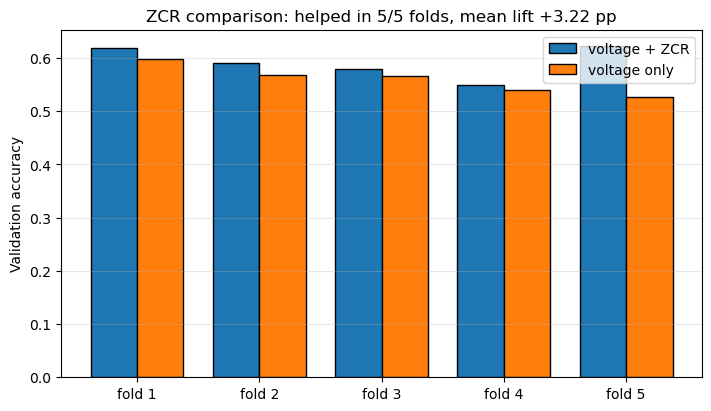

In [8]:
# ── §2c ZCR feature ablation: voltage-only CV + paired lift vs voltage+ZCR ──
# Occlusion (in §3) measures how much the trained 2-channel model *leans on* each
# input; this cell answers a different question — was ZCR worth adding in the
# first place? Retrain the same architecture on the voltage-only input (no ZCR
# channel) under the SAME 5 GroupKFold splits, same recipe, same TF_SEED as §2b,
# then compute the paired per-fold accuracy lift (mean lift, 95% t-based CI,
# one-sided sign test under a fair-coin null).
# RETRAIN_VOLT=False reloads existing fold_*.keras instead of retraining.
RETRAIN_VOLT = False

VOLT_DIR = TEMP_DIR / 'voltage_only'
VOLT_MODEL_DIR = VOLT_DIR / 'models'
VOLT_DIR.mkdir(parents=True, exist_ok=True)
VOLT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# --- Build voltage-only tensor (drop ZCR channel before z-scoring) ---------
x_volt_only_bin = x_full[:, idx_bins, :, :, :].copy()   # (N, 28, H, W, 1)
x_volt_only = x_volt_only_bin.copy()
for s in sorted(set(g_all.tolist())):
    m = g_all == s
    mu = x_volt_only_bin[m].mean(axis=0, keepdims=True)
    sd = x_volt_only_bin[m].std(axis=0, keepdims=True) + 1e-6
    x_volt_only[m] = (x_volt_only_bin[m] - mu) / sd
print(f'voltage-only tensor : {x_volt_only.shape}   # (N, T=28, H, W, C=1)')
print(f'2-channel reference : {x_all.shape}         # (N, T=28, H, W, C=2)')

# --- 5-fold CV on voltage-only input ---------------------------------------
input_shape_volt = tuple(x_volt_only.shape[1:])
gkf_volt = GroupKFold(n_splits=N_CV_FOLDS)
fold_iter_volt = list(enumerate(gkf_volt.split(x_volt_only, y_all, groups=g_all), start=1))

oof_p_volt = np.full(len(y_all), np.nan, dtype=np.float64)
fold_rows_volt = []

for fold_num, (fit_idx, val_idx) in tqdm(fold_iter_volt, desc='5-fold CV (voltage-only)',
                                       total=N_CV_FOLDS, unit='fold'):
    model_path = VOLT_MODEL_DIR / f'fold_{fold_num}.keras'
    g_val_set = sorted(set(g_all[val_idx].tolist()))
    X_fit, y_fit = x_volt_only[fit_idx], y_all[fit_idx]
    X_val, y_val = x_volt_only[val_idx], y_all[val_idx]

    if RETRAIN_VOLT or not model_path.exists():
        print(f'\n=== fold {fold_num}: fit n={len(fit_idx)} ({len(set(g_all[fit_idx].tolist()))} subj),',
              f' val n={len(val_idx)} ({len(g_val_set)} subj) ===')
        print(f'  val subjects: {g_val_set}')
        seed_everything(TF_SEED)
        model = build_best_model(input_shape_volt, BEST_CFG)
        hist = model.fit(
            X_fit, y_fit,
            validation_data=(X_val, y_val),
            epochs=TRAIN_EPOCHS,
            batch_size=BEST_CFG['batch_size'],
            verbose=TRAIN_VERBOSE,
        )
        model.save(model_path)
        epochs_ran = len(hist.history['loss'])
    else:
        print(f'\n=== fold {fold_num}: loading existing {model_path.name} ===')
        model = tf.keras.models.load_model(model_path)
        epochs_ran = -1

    p_fit = model.predict(X_fit, verbose=0).ravel()
    m_fit = metric_pack(y_fit, p_fit)

    p_val = model.predict(X_val, verbose=0).ravel()
    oof_p_volt[val_idx] = p_val
    m = metric_pack(y_val, p_val)
    fold_rows_volt.append({
        'fold': fold_num,
        'n_fit': int(len(fit_idx)),
        'n_val': int(len(val_idx)),
        'val_subjects': ';'.join(g_val_set),
        'epochs_ran': int(epochs_ran),
        'model_path': str(model_path),
        **{f'train_{k}': v for k, v in m_fit.items() if k != 'cm'},
        'train_cm': json.dumps(m_fit['cm']),
        **{f'val_{k}': v for k, v in m.items() if k != 'cm'},
        'val_cm': json.dumps(m['cm']),
    })
    print(f"  -> train acc={m_fit['accuracy']:.4f}  val acc={m['accuracy']:.4f}  "
          f"gap={m_fit['accuracy']-m['accuracy']:+.4f}  "
          f"bal_acc={m['balanced_accuracy']:.4f}  f1={m['f1']:.4f}  auc={m['roc_auc']:.4f}")
    del model
    tf.keras.backend.clear_session()

assert not np.isnan(oof_p_volt).any(), 'some trials were never assigned to a val fold'
cv_df_volt = pd.DataFrame(fold_rows_volt)
cv_df_volt.to_csv(VOLT_DIR / 'cv_per_fold.csv', index=False)
print('\nSaved per-fold CV metrics (voltage-only).')

# ── Paired comparison: voltage+ZCR vs voltage-only (per-fold OOF acc) ────
acc_2ch  = cv_df['val_accuracy'].to_numpy()           # voltage + ZCR
acc_volt = cv_df_volt['val_accuracy'].to_numpy()      # voltage only
delta    = acc_2ch - acc_volt                          # paired per-fold

mean_d = float(delta.mean())
sd_d   = float(delta.std(ddof=1))
t_crit = sps.t.ppf(0.975, df=len(delta) - 1)
ci_d   = t_crit * sd_d / np.sqrt(len(delta))
n_pos  = int((delta > 0).sum())
# One-sided sign test: P(>= n_pos heads in N flips of a fair coin)
from math import comb
sign_p = sum(comb(N_CV_FOLDS, k) for k in range(n_pos, N_CV_FOLDS + 1)) / (2 ** N_CV_FOLDS)

cmp_df = pd.DataFrame({
    'fold'           : np.arange(1, N_CV_FOLDS + 1),
    'acc_volt_zcr'   : acc_2ch,
    'acc_volt_only'  : acc_volt,
    'delta_zcr_gain' : delta,
})
print('\n=== Per-fold accuracy: voltage+ZCR vs voltage-only ===')
print(cmp_df.round(4).to_string(index=False))
print(f'\nZCR helped in {n_pos}/{N_CV_FOLDS} folds  (one-sided sign test p={sign_p:.3f})')
print(f'mean ZCR lift = {mean_d*100:+.2f} pp  (95% CI [{(mean_d-ci_d)*100:+.2f}, {(mean_d+ci_d)*100:+.2f}] pp)')

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
x = np.arange(1, N_CV_FOLDS + 1)
w = 0.38
ax.bar(x - w/2, acc_2ch,  width=w, label='voltage + ZCR', color='C0', edgecolor='k')
ax.bar(x + w/2, acc_volt, width=w, label='voltage only',  color='C1', edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in x])
ax.set_ylabel('Validation accuracy')
ax.set_title(f'ZCR comparison: helped in {n_pos}/{N_CV_FOLDS} folds, mean lift {mean_d*100:+.2f} pp')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.show()


## 3. Results — occlusion sensitivity

Following Zeiler & Fergus (2014) as adapted to EEG by Grubov et al. (2026, Eq. 8): each spatial / temporal / spatiotemporal cell is **replaced with the per-trial pre-stim baseline of the same channel** (`x_baseline` from §1) rather than zeroed, which would push the input off-distribution. The importance of that cell is the mean **|Δp|** — absolute change in the model's sigmoid output — across the fold's held-out trials, aggregated across the 5 CV folds.

**a (occlusion)** loads each fold's trained model and runs three class-specific occlusion passes on its held-out trials — temporal (one bin at a time), spatial (one (H, W) grid cell at a time), and spatiotemporal 3D (every bin × H × W combination) — splitting the trials into Cit vs Cyc subsets *before* averaging |Δp|. All per-fold arrays are cached to `temp/per_fold_arrays/` so b and c can be re-rendered without re-running any model. Two cache flags control recomputation:
- `RECOMPUTE_CLS` — when `True`, re-runs the cheap 2D pass (`sp_cit`, `sp_cyc`, `temp_cit`, `temp_cyc`, `fold_base_cit`, `fold_base_cyc`). Default `False` loads from cache.
- `RECOMPUTE_CLS3D` — when `True`, re-runs the heavy spatiotemporal 3D pass (`sp3d_cit`, `sp3d_cyc`). Default `False` loads from cache. Kept independent of `RECOMPUTE_CLS` so the (much slower) 3D pass can be redone without redoing 2D.

**b (aggregate figure generation)** averages the per-fold arrays into cross-fold summary figures: the Cit − Cyc spatial topomap, the class-specific temporal |Δp| curves with analytical t-based 95% CI ribbons, and the Early / Mid / Late spatiotemporal Cit − Cyc topomaps.

**c (per-fold figures)** renders one figure per CV fold (`temp/per_fold_figures/occlusion_fold{1..5}.png`) showing that fold's Cit − Cyc spatial topomap, its Cit vs Cyc temporal |Δp| line plot, and its Early / Mid / Late Cit − Cyc topomaps — each scaled to a per-fold vmax so smaller-range folds aren't washed out.


In [ ]:
# ── §3a Occlusion compute (class-specific only) ─────────────────────────────
# Runs three class-specific occlusion passes on each fold's held-out trials:
#   - temporal  (one of 28 bins replaced at a time)
#   - spatial   (one (row, col) grid cell replaced across all bins)
#   - spatiotemporal 3D (every bin x row x col cell replaced independently)
# For each pass, the held-out trials are split into Cit vs Cyc subsets BEFORE
# averaging |Δp|, producing the per-class arrays (sp_cit/sp_cyc/temp_cit/...)
# that §3b aggregates into figures and §3c slices for per-fold panels.
#
# Two cache flags so the (heavy) 3D pass can be redone without redoing the
# (cheap) 2D pass:
#   RECOMPUTE_CLS    -> sp_cit, sp_cyc, temp_cit, temp_cyc, fold_base_{cit,cyc}
#   RECOMPUTE_CLS3D  -> sp3d_cit, sp3d_cyc  (n_bins x H x W x folds, per class)
RECOMPUTE_CLS   = False
RECOMPUTE_CLS3D = False

PF_DIR = TEMP_DIR / 'per_fold_arrays'
PF_DIR.mkdir(exist_ok=True)
n_bins, H, W, C = x_all.shape[1:]

_cls2d_files = ['sp_cit.npy', 'sp_cyc.npy', 'temp_cit.npy', 'temp_cyc.npy',
                'fold_base_cit.npy', 'fold_base_cyc.npy', 'base_acc.npy']
_cls3d_files = ['sp3d_cit.npy', 'sp3d_cyc.npy']
_use_cls2d = (not RECOMPUTE_CLS)   and all((PF_DIR / f).exists() for f in _cls2d_files)
_use_cls3d = (not RECOMPUTE_CLS3D) and all((PF_DIR / f).exists() for f in _cls3d_files)

fold_models = None
fold_val    = None

def _ensure_fold_models():
    """Load fold_*.keras + build fold_val (X / X_base / y / base_p / base_acc).
    Idempotent: returns immediately if already populated."""
    global fold_models, fold_val
    if fold_models is not None and fold_val is not None and 'X' in fold_val[0]:
        return
    # Compat shim: older TF saved BatchNormalization with `renorm*` kwargs that
    # newer Keras rejects. Strip them before deserialization.
    _orig = tf.keras.layers.BatchNormalization.__init__
    def _patched(self, *args, **kwargs):
        for _k in ('renorm', 'renorm_clipping', 'renorm_momentum'):
            kwargs.pop(_k, None)
        _orig(self, *args, **kwargs)
    tf.keras.layers.BatchNormalization.__init__ = _patched
    fold_models = []
    for _k in range(N_CV_FOLDS):
        _pp = MODEL_DIR / f'fold_{_k+1}.keras'
        if not _pp.exists():
            raise FileNotFoundError(f'{_pp} missing - rerun the §2b CV cell first.')
        fold_models.append(tf.keras.models.load_model(_pp))
        print(f'  loaded {_pp.name}')
    _fv_idx = [val for _, val in GroupKFold(n_splits=N_CV_FOLDS).split(x_all, y_all, groups=g_all)]
    fold_val = []
    for _k, _vi in enumerate(_fv_idx):
        _Xv, _Bv, _yv = x_all[_vi], x_baseline[_vi], y_all[_vi]
        _pb = fold_models[_k].predict(_Xv, verbose=0).ravel()
        fold_val.append({'X': _Xv, 'X_base': _Bv, 'y': _yv, 'base_p': _pb,
                         'base_acc': float(accuracy_score(_yv, (_pb >= THR).astype(int))),
                         'n': len(_yv)})
    print('Fold models + held-out predictions loaded.')

# ── 2-D pass (spatial + temporal per class) ───────────────────────────────
if _use_cls2d:
    sp_cit        = np.load(PF_DIR / 'sp_cit.npy')
    sp_cyc        = np.load(PF_DIR / 'sp_cyc.npy')
    temp_cit      = np.load(PF_DIR / 'temp_cit.npy')
    temp_cyc      = np.load(PF_DIR / 'temp_cyc.npy')
    fold_base_cit = np.load(PF_DIR / 'fold_base_cit.npy')
    fold_base_cyc = np.load(PF_DIR / 'fold_base_cyc.npy')
    base_acc_arr  = np.load(PF_DIR / 'base_acc.npy')
    if fold_val is None:
        fold_val = [{'base_acc': float(a)} for a in base_acc_arr]
    print('Loaded cached 2D per-class arrays.')
    print(f'  spatial arrays : sp_cit  ={sp_cit.shape},  sp_cyc  ={sp_cyc.shape}')
    print(f'  temporal arrays: temp_cit={temp_cit.shape}, temp_cyc={temp_cyc.shape}')
else:
    _ensure_fold_models()
    sp_cit = np.zeros((H, W, N_CV_FOLDS))
    sp_cyc = np.zeros((H, W, N_CV_FOLDS))
    fold_base_cit = np.zeros(N_CV_FOLDS)
    fold_base_cyc = np.zeros(N_CV_FOLDS)

    fold_cls = []
    for k, fv in enumerate(fold_val):
        cit = np.where(fv['y'] == 0)[0]; cyc = np.where(fv['y'] == 1)[0]
        fold_cls.append({'cit_idx': cit, 'cyc_idx': cyc,
                         'pc_base': fv['base_p'][cit], 'py_base': fv['base_p'][cyc]})
        fold_base_cit[k] = float(accuracy_score(
            fv['y'][cit],
            (fold_models[k].predict(fv['X'][cit], verbose=0).ravel() >= THR).astype(int)))
        fold_base_cyc[k] = float(accuracy_score(
            fv['y'][cyc],
            (fold_models[k].predict(fv['X'][cyc], verbose=0).ravel() >= THR).astype(int)))

    for i in tqdm(range(H), desc='Spatial occlusion (per-class, per-fold, |Δp|)'):
        for j in range(W):
            for k, (fv, fc) in enumerate(zip(fold_val, fold_cls)):
                cit, cyc = fc['cit_idx'], fc['cyc_idx']
                Xc, Bc = fv['X'][cit], fv['X_base'][cit]
                Xy, By = fv['X'][cyc], fv['X_base'][cyc]
                Xoc = Xc.copy(); Xoc[:, :, i, j, :] = Bc[:, :, i, j, :]
                Xoy = Xy.copy(); Xoy[:, :, i, j, :] = By[:, :, i, j, :]
                pc_occ = fold_models[k].predict(Xoc, verbose=0).ravel()
                py_occ = fold_models[k].predict(Xoy, verbose=0).ravel()
                sp_cit[i, j, k] = float(np.mean(np.abs(fc['pc_base'] - pc_occ)))
                sp_cyc[i, j, k] = float(np.mean(np.abs(fc['py_base'] - py_occ)))
    print('Spatial 2D occlusion done.')
    print(f'  spatial arrays: sp_cit={sp_cit.shape}, sp_cyc={sp_cyc.shape}')

    temp_cit = np.zeros((n_bins, N_CV_FOLDS))
    temp_cyc = np.zeros((n_bins, N_CV_FOLDS))
    for b in tqdm(range(n_bins), desc='Temporal occlusion (per-class, per-fold, |Δp|)'):
        for k, (fv, fc) in enumerate(zip(fold_val, fold_cls)):
            cit, cyc = fc['cit_idx'], fc['cyc_idx']
            Xc, Bc = fv['X'][cit], fv['X_base'][cit]
            Xy, By = fv['X'][cyc], fv['X_base'][cyc]
            Xoc = Xc.copy(); Xoc[:, b, :, :, :] = Bc[:, b, :, :, :]
            Xoy = Xy.copy(); Xoy[:, b, :, :, :] = By[:, b, :, :, :]
            pc_occ = fold_models[k].predict(Xoc, verbose=0).ravel()
            py_occ = fold_models[k].predict(Xoy, verbose=0).ravel()
            temp_cit[b, k] = float(np.mean(np.abs(fc['pc_base'] - pc_occ)))
            temp_cyc[b, k] = float(np.mean(np.abs(fc['py_base'] - py_occ)))
    print('Temporal 2D occlusion done.')
    print(f'  temporal arrays: temp_cit={temp_cit.shape}, temp_cyc={temp_cyc.shape}')

    np.save(PF_DIR / 'sp_cit.npy',        sp_cit)
    np.save(PF_DIR / 'sp_cyc.npy',        sp_cyc)
    np.save(PF_DIR / 'temp_cit.npy',      temp_cit)
    np.save(PF_DIR / 'temp_cyc.npy',      temp_cyc)
    np.save(PF_DIR / 'fold_base_cit.npy', fold_base_cit)
    np.save(PF_DIR / 'fold_base_cyc.npy', fold_base_cyc)
    np.save(PF_DIR / 'base_acc.npy',      np.array([f['base_acc'] for f in fold_val]))
    np.save(PF_DIR / 'bin_times.npy',     bin_times)
    print('Saved class-specific 2D per-fold arrays.')

# ── 3-D pass (n_bins x H x W per class) ───────────────────────────────────
if _use_cls3d:
    sp3d_cit = np.load(PF_DIR / 'sp3d_cit.npy')
    sp3d_cyc = np.load(PF_DIR / 'sp3d_cyc.npy')
    print('Loaded cached 3D per-class arrays.')
    print(f'  spatiotemporal arrays: sp3d_cit={sp3d_cit.shape}, sp3d_cyc={sp3d_cyc.shape}')
else:
    _ensure_fold_models()
    fold_cls = []
    for k, fv in enumerate(fold_val):
        cit = np.where(fv['y'] == 0)[0]; cyc = np.where(fv['y'] == 1)[0]
        fold_cls.append({'cit_idx': cit, 'cyc_idx': cyc,
                         'pc_base': fv['base_p'][cit], 'py_base': fv['base_p'][cyc]})
    sp3d_cit = np.zeros((n_bins, H, W, N_CV_FOLDS))
    sp3d_cyc = np.zeros((n_bins, H, W, N_CV_FOLDS))
    for b in tqdm(range(n_bins), desc='3D occlusion (per-class, bins)'):
        for i in range(H):
            for j in range(W):
                for k, (fv, fc) in enumerate(zip(fold_val, fold_cls)):
                    cit, cyc = fc['cit_idx'], fc['cyc_idx']
                    Xc, Bc = fv['X'][cit], fv['X_base'][cit]
                    Xy, By = fv['X'][cyc], fv['X_base'][cyc]
                    Xoc = Xc.copy(); Xoc[:, b, i, j, :] = Bc[:, b, i, j, :]
                    Xoy = Xy.copy(); Xoy[:, b, i, j, :] = By[:, b, i, j, :]
                    pc_occ = fold_models[k].predict(Xoc, verbose=0).ravel()
                    py_occ = fold_models[k].predict(Xoy, verbose=0).ravel()
                    sp3d_cit[b, i, j, k] = float(np.mean(np.abs(fc['pc_base'] - pc_occ)))
                    sp3d_cyc[b, i, j, k] = float(np.mean(np.abs(fc['py_base'] - py_occ)))
    print('Spatiotemporal 3D occlusion done.')
    print(f'  spatiotemporal arrays: sp3d_cit={sp3d_cit.shape}, sp3d_cyc={sp3d_cyc.shape}')
    np.save(PF_DIR / 'sp3d_cit.npy', sp3d_cit)
    np.save(PF_DIR / 'sp3d_cyc.npy', sp3d_cyc)
    print('Saved class-specific 3D per-fold arrays.')

# ── Per-fold baseline accuracies (used by §3c titles + §3b summary) ───────
print(f'\nOOF baseline acc (per-fold mean +/- SD):'
      f' {np.mean([f["base_acc"] for f in fold_val]):.4f}'
      f' +/- {np.std([f["base_acc"] for f in fold_val], ddof=1):.4f}')

# ── Shared helpers for §3b (aggregate figs) and §3c (per-fold figs) ───────
t_crit = sps.t.ppf(0.975, df=N_CV_FOLDS - 1)

coord_df_cc = kato_metadata['channel_positions']
row_idx_cc  = kato_metadata['row_idx']
col_idx_cc  = kato_metadata['col_idx']
ch_names_cc = coord_df_cc['channel'].tolist()

info_cc = mne.create_info(ch_names=ch_names_cc, sfreq=100, ch_types='eeg')
info_cc.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False)

thirds = np.array_split(np.arange(n_bins), 3)
window_names = ['Early', 'Mid', 'Late']


Cit OOF baseline acc (mean, 95% CI): 0.6159  [0.5808, 0.6511]
Cyc OOF baseline acc (mean, 95% CI): 0.5680  [0.4643, 0.6717]


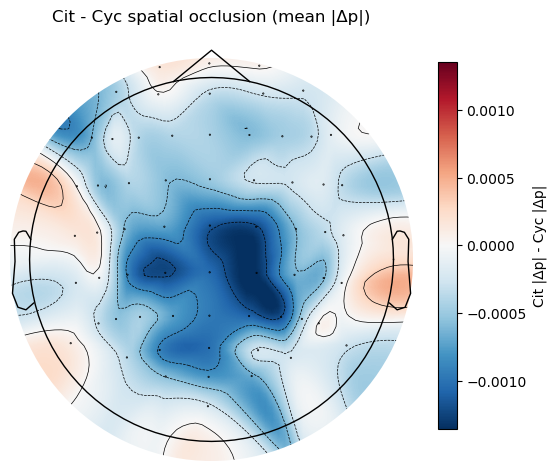

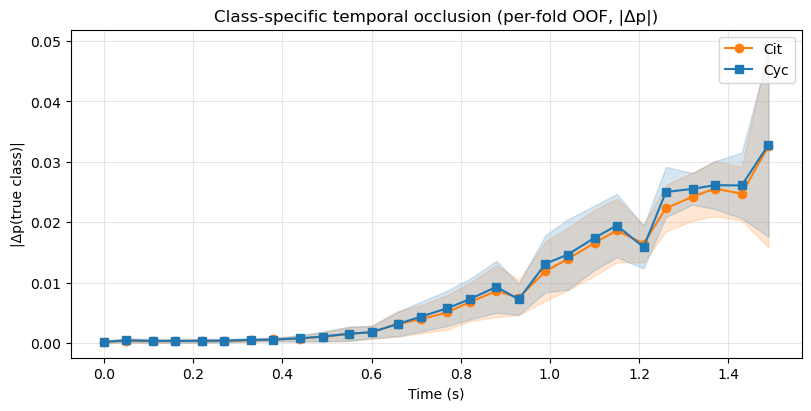

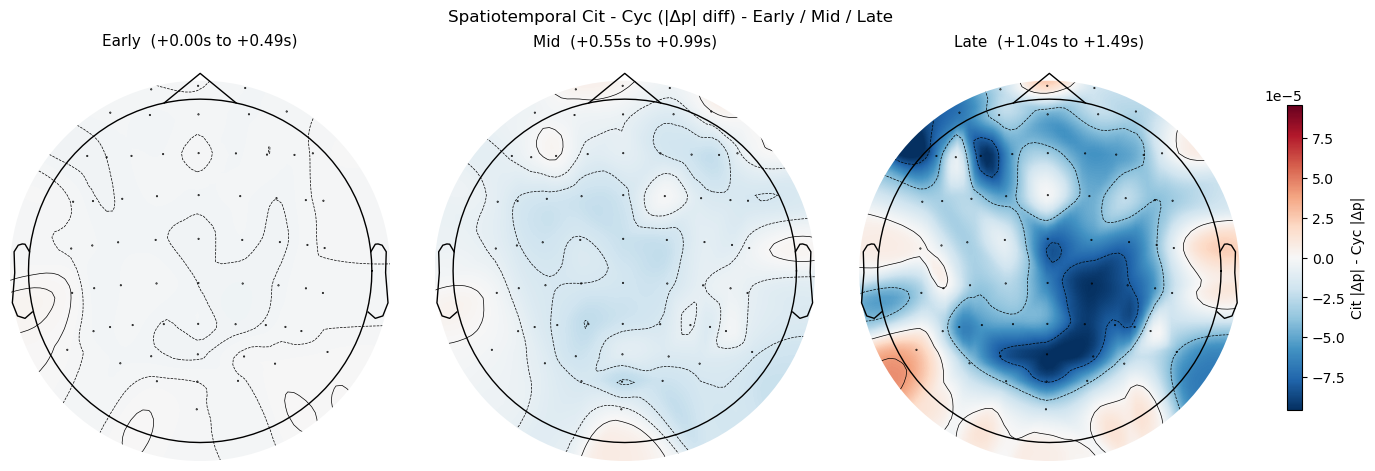

In [10]:
# ── §3b Aggregate cross-fold figures (class-specific) ─────────────────────
# All inputs come from §3a:
#   sp_cit, sp_cyc            (H, W, folds)
#   temp_cit, temp_cyc        (n_bins, folds)
#   sp3d_cit, sp3d_cyc        (n_bins, H, W, folds)
#   fold_base_cit, fold_base_cyc
#   t_crit, info_cc, row_idx_cc, col_idx_cc, ch_names_cc, thirds, window_names

# ── Cit/Cyc OOF baseline accuracy (mean ± t-based 95% CI) ─────────────────
_ci_cit = t_crit * fold_base_cit.std(ddof=1) / np.sqrt(N_CV_FOLDS)
_ci_cyc = t_crit * fold_base_cyc.std(ddof=1) / np.sqrt(N_CV_FOLDS)
print(f'Cit OOF baseline acc (mean, 95% CI): {fold_base_cit.mean():.4f}  '
      f'[{fold_base_cit.mean()-_ci_cit:.4f}, {fold_base_cit.mean()+_ci_cit:.4f}]')
print(f'Cyc OOF baseline acc (mean, 95% CI): {fold_base_cyc.mean():.4f}  '
      f'[{fold_base_cyc.mean()-_ci_cyc:.4f}, {fold_base_cyc.mean()+_ci_cyc:.4f}]')

# ── Cross-fold means (used by all three figures) ─────────────────────────
sp_cit_mean = sp_cit.mean(axis=2)
sp_cyc_mean = sp_cyc.mean(axis=2)
elec_cit  = np.array([sp_cit_mean[r, c] for r, c in zip(row_idx_cc, col_idx_cc)])
elec_cyc  = np.array([sp_cyc_mean[r, c] for r, c in zip(row_idx_cc, col_idx_cc)])
elec_diff = elec_cit - elec_cyc

# ── Figure: Cit - Cyc spatial topomap ─────────────────────────────────────
vd = max(abs(np.nanmin(elec_diff)), abs(np.nanmax(elec_diff))) or 1e-6
fig, ax = plt.subplots(figsize=(6.5, 4.6), constrained_layout=True)
im, _ = mne.viz.plot_topomap(elec_diff, info_cc, axes=ax, cmap='RdBu_r', show=False,
                             vlim=(-vd, vd), contours=6, extrapolate='head')
ax.set_title('Cit - Cyc spatial occlusion (mean |Δp|)')
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.05)
cb.set_label('Cit |Δp| - Cyc |Δp|')
plt.show()

# ── Figure: temporal |Δp| by class (with analytical t-based CI ribbon) ────
cit_mean = temp_cit.mean(axis=1); cit_sd = temp_cit.std(axis=1, ddof=1)
cyc_mean = temp_cyc.mean(axis=1); cyc_sd = temp_cyc.std(axis=1, ddof=1)
cit_ci   = t_crit * cit_sd / np.sqrt(N_CV_FOLDS)
cyc_ci   = t_crit * cyc_sd / np.sqrt(N_CV_FOLDS)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(bin_times, cit_mean, marker='o', linewidth=1.5, color='tab:orange', label='Cit')
ax.plot(bin_times, cyc_mean, marker='s', linewidth=1.5, color='tab:blue',   label='Cyc')
ax.fill_between(bin_times, cit_mean - cit_ci, cit_mean + cit_ci, color='tab:orange', alpha=0.18)
ax.fill_between(bin_times, cyc_mean - cyc_ci, cyc_mean + cyc_ci, color='tab:blue',   alpha=0.18)
ax.set_title('Class-specific temporal occlusion (per-fold OOF, |Δp|)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('|Δp(true class)|')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# ── Figure: Early / Mid / Late Cit-Cyc topomaps (from class-specific 3D) ──
sp3d_diff_mean = sp3d_cit.mean(axis=3) - sp3d_cyc.mean(axis=3)
window_elec_diff = []
for w_bins in thirds:
    win = sp3d_diff_mean[w_bins].mean(axis=0)
    window_elec_diff.append(np.array([win[r, c] for r, c in zip(row_idx_cc, col_idx_cc)]))
vmax_wd = float(max(np.max(np.abs(e)) for e in window_elec_diff)) or 1e-6

fig, axs = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
last_im = None
for ax, name, elec, w_bins in zip(axs, window_names, window_elec_diff, thirds):
    t0, t1 = bin_times[w_bins[0]], bin_times[w_bins[-1]]
    last_im, _ = mne.viz.plot_topomap(elec, info_cc, axes=ax, cmap='RdBu_r',
                                      vlim=(-vmax_wd, vmax_wd), show=False,
                                      contours=4, extrapolate='head')
    ax.set_title(f'{name}  ({t0:+.2f}s to {t1:+.2f}s)', fontsize=11)
cb = fig.colorbar(last_im, ax=axs, shrink=0.75, pad=0.02)
cb.set_label('Cit |Δp| - Cyc |Δp|')
fig.suptitle('Spatiotemporal Cit - Cyc (|Δp| diff) - Early / Mid / Late', fontsize=12)
plt.show()


Saved per-fold class-specific arrays.


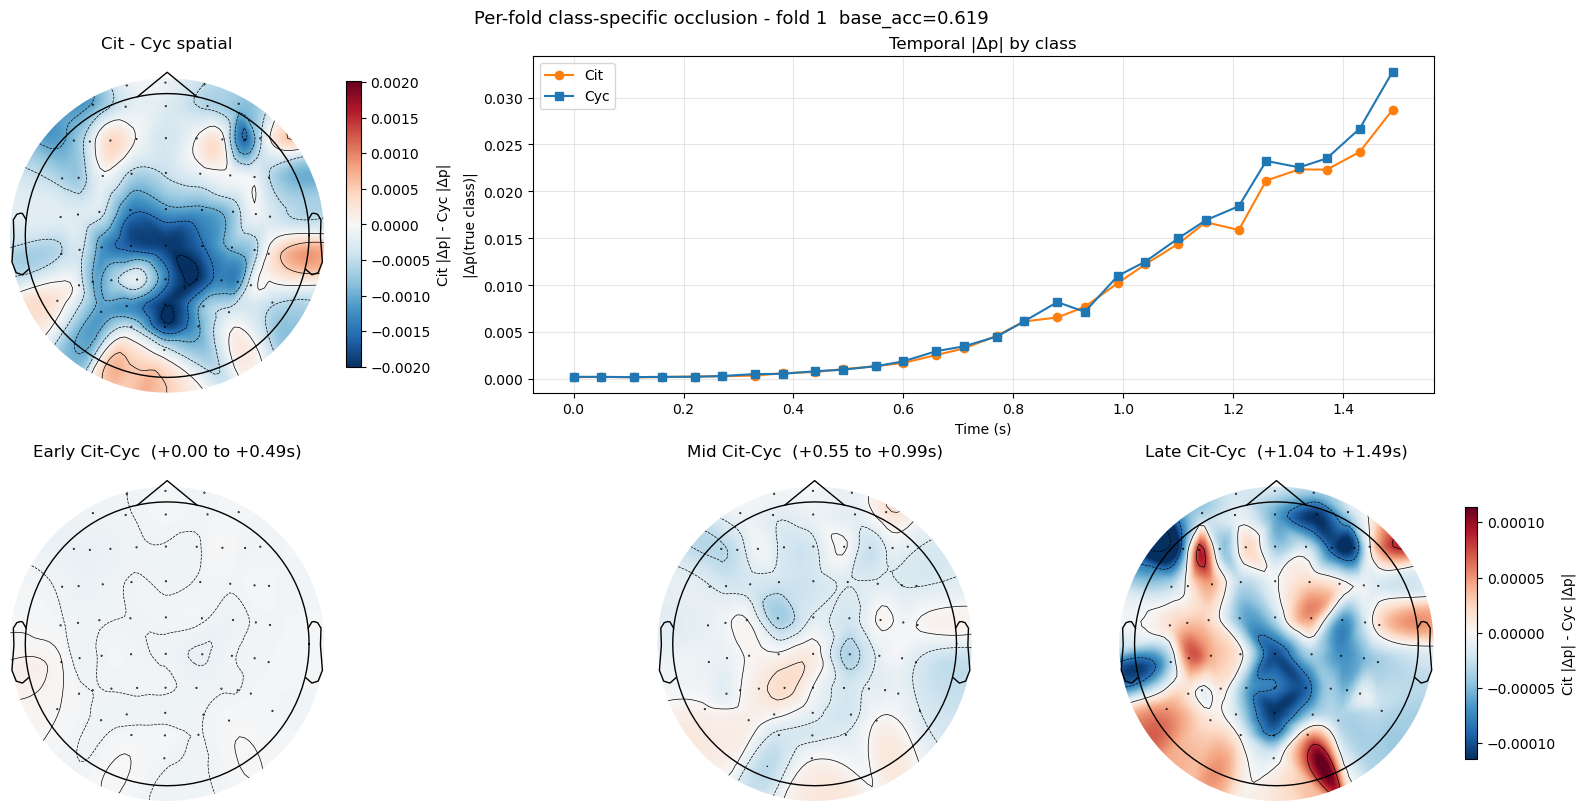

Saved fold 1 figure.


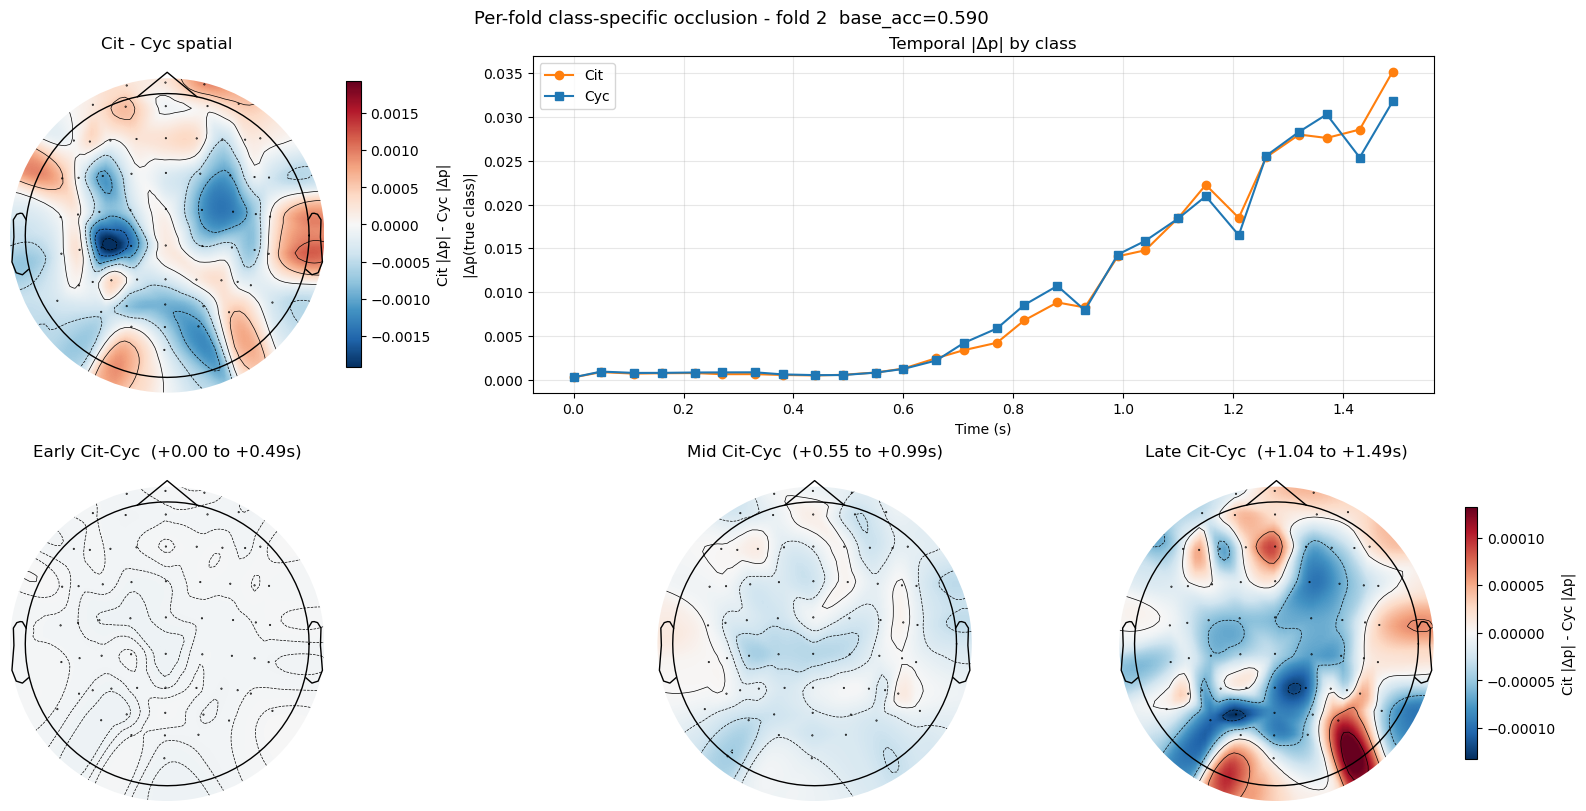

Saved fold 2 figure.


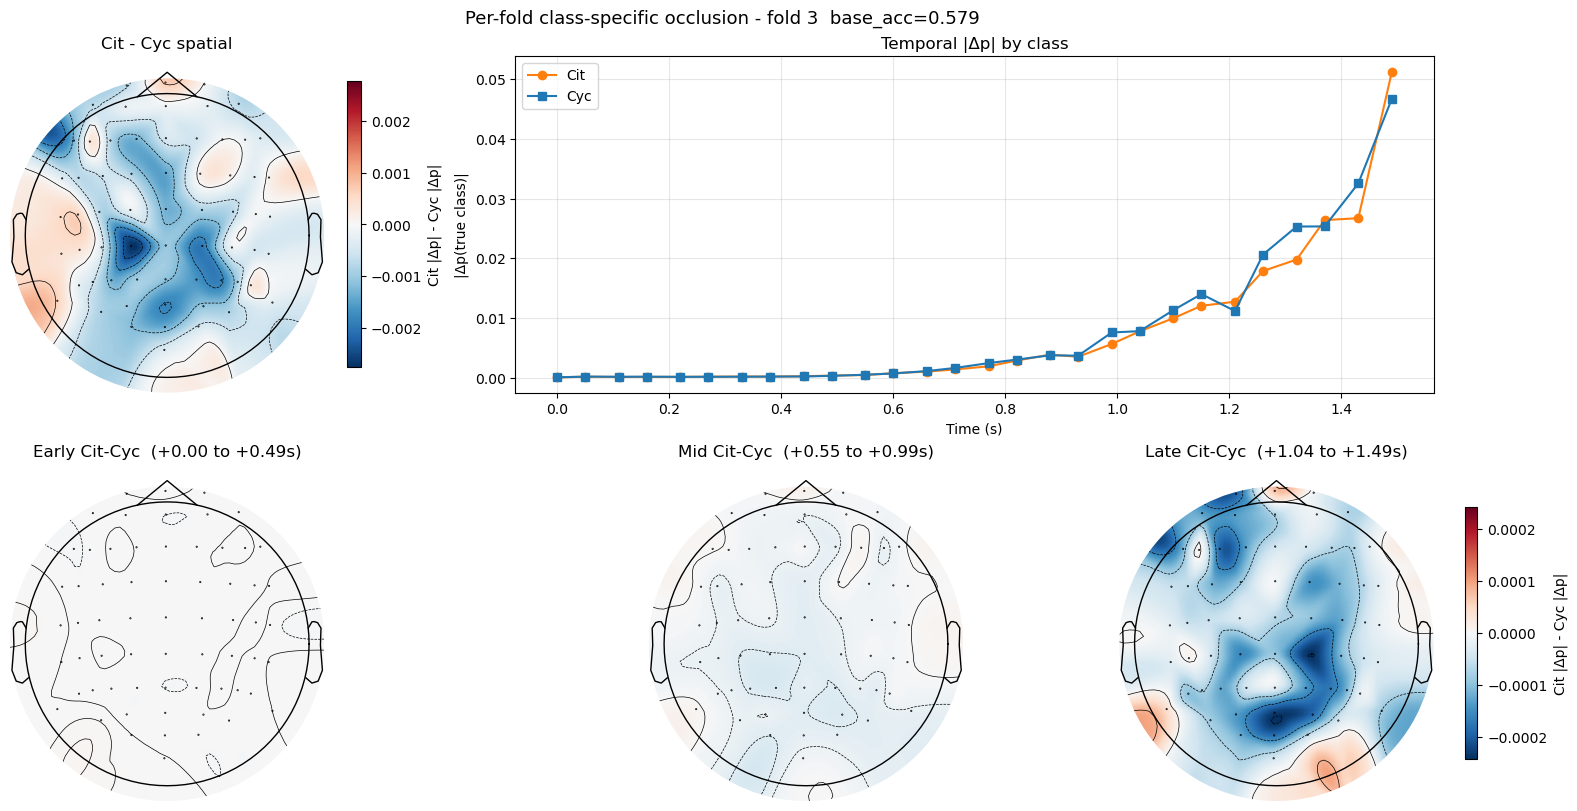

Saved fold 3 figure.


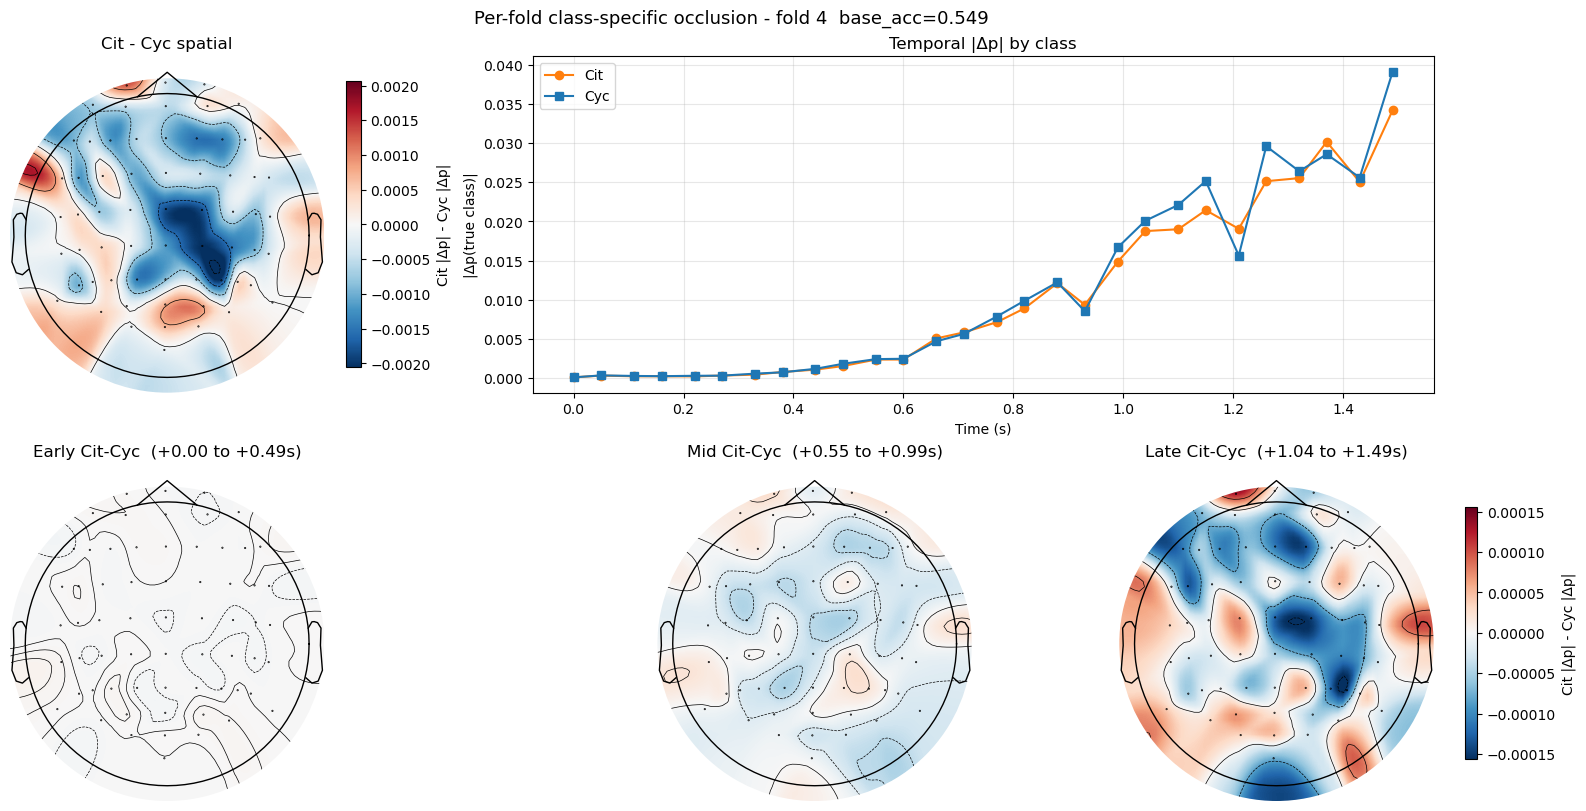

Saved fold 4 figure.


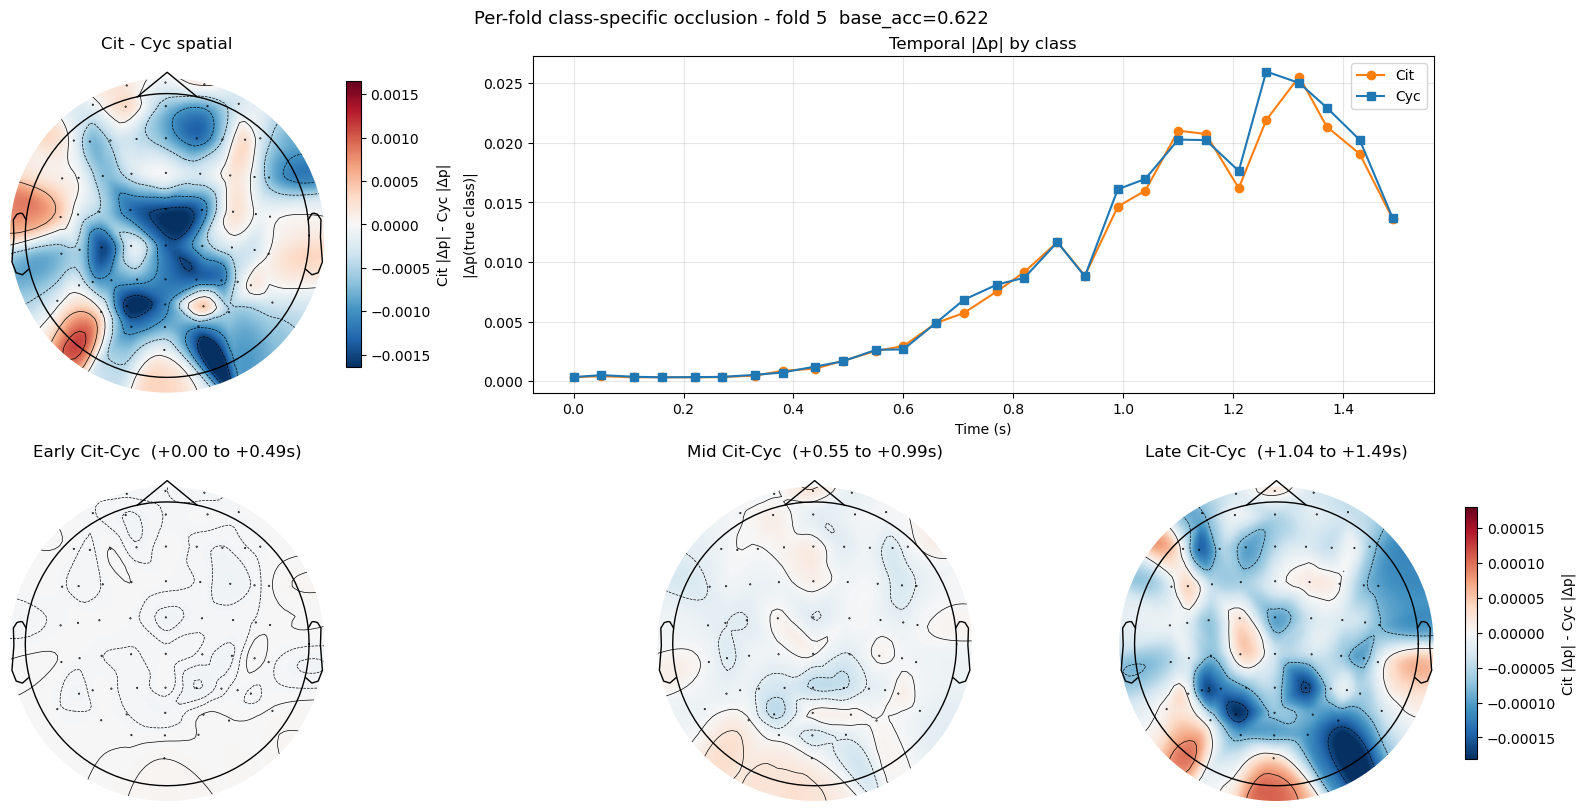

Saved fold 5 figure.


In [11]:
# ── Per-fold occlusion figures (all folds) — simplified (Cit-Cyc only) ──
PF_DIR  = TEMP_DIR / 'per_fold_arrays'
FIG_DIR = TEMP_DIR / 'per_fold_figures'
PF_DIR.mkdir(exist_ok=True); FIG_DIR.mkdir(exist_ok=True)

np.save(PF_DIR / 'sp_cit.npy',     sp_cit)
np.save(PF_DIR / 'sp_cyc.npy',     sp_cyc)
np.save(PF_DIR / 'sp3d_cit.npy',   sp3d_cit)
np.save(PF_DIR / 'sp3d_cyc.npy',   sp3d_cyc)
np.save(PF_DIR / 'temp_cit.npy',   temp_cit)
np.save(PF_DIR / 'temp_cyc.npy',   temp_cyc)
np.save(PF_DIR / 'bin_times.npy',  bin_times)
print('Saved per-fold class-specific arrays.')

# Per-fold vmax (each fold scaled to its own range so panels aren't washed out).
for k in range(N_CV_FOLDS):
    diff_k    = sp_cit[:, :, k] - sp_cyc[:, :, k]
    s3_diff_k = sp3d_cit[:, :, :, k] - sp3d_cyc[:, :, :, k]
    tc_k = temp_cit[:, k]
    ty_k = temp_cyc[:, k]
    elec_diff_k = np.array([diff_k[r, c] for r, c in zip(row_idx_cc, col_idx_cc)])

    vmax_sp_k = float(np.max(np.abs(elec_diff_k))) or 1e-6

    win_elecs_k = []
    for w_bins in thirds:
        win = s3_diff_k[w_bins].mean(axis=0)
        win_elecs_k.append(np.array([win[r, c] for r, c in zip(row_idx_cc, col_idx_cc)]))
    vmax_wd_k = float(max(np.max(np.abs(e)) for e in win_elecs_k)) or 1e-6

    fig = plt.figure(figsize=(17, 8), constrained_layout=True)
    gs  = fig.add_gridspec(2, 3)

    ax_dif = fig.add_subplot(gs[0, 0])
    im_sp, _ = mne.viz.plot_topomap(elec_diff_k, info_cc, axes=ax_dif, cmap='RdBu_r',
                                    show=False, vlim=(-vmax_sp_k, vmax_sp_k),
                                    contours=6, extrapolate='head')
    ax_dif.set_title('Cit - Cyc spatial')
    cb_sp = fig.colorbar(im_sp, ax=ax_dif, shrink=0.85, pad=0.05)
    cb_sp.set_label('Cit |Δp| - Cyc |Δp|')

    ax_tt = fig.add_subplot(gs[0, 1:])
    ax_tt.plot(bin_times, tc_k, marker='o', color='tab:orange', label='Cit')
    ax_tt.plot(bin_times, ty_k, marker='s', color='tab:blue',   label='Cyc')
    ax_tt.set_xlabel('Time (s)'); ax_tt.set_ylabel('|Δp(true class)|')
    ax_tt.set_title('Temporal |Δp| by class')
    ax_tt.grid(alpha=0.3); ax_tt.legend()

    win_axes = []
    last_im_w = None
    for ax_i, (name, w_bins, elec) in enumerate(zip(window_names, thirds, win_elecs_k)):
        ax = fig.add_subplot(gs[1, ax_i])
        last_im_w, _ = mne.viz.plot_topomap(elec, info_cc, axes=ax, cmap='RdBu_r',
                                            show=False, vlim=(-vmax_wd_k, vmax_wd_k),
                                            contours=4, extrapolate='head')
        t0, t1 = bin_times[w_bins[0]], bin_times[w_bins[-1]]
        ax.set_title(f'{name} Cit-Cyc  ({t0:+.2f} to {t1:+.2f}s)')
        win_axes.append(ax)
    cb_w = fig.colorbar(last_im_w, ax=win_axes, shrink=0.75, pad=0.02)
    cb_w.set_label('Cit |Δp| - Cyc |Δp|')

    fig.suptitle(f'Per-fold class-specific occlusion - fold {k+1}  '
                 f'base_acc={fold_val[k]["base_acc"]:.3f}', fontsize=13)

    out = FIG_DIR / f'occlusion_fold{k+1}.png'
    fig.savefig(out, dpi=160)
    plt.show()
    print(f'Saved fold {k+1} figure.')